In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")

df = pd.read_csv("../data/WA_Fn-UseC_-Telco-Customer-Churn.csv")
print(df.shape)
df.head()


(7043, 21)


,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


Churn
No     5174
Yes    1869
Name: count, dtype: int64
Churn
No     0.735
Yes    0.265
Name: proportion, dtype: float64


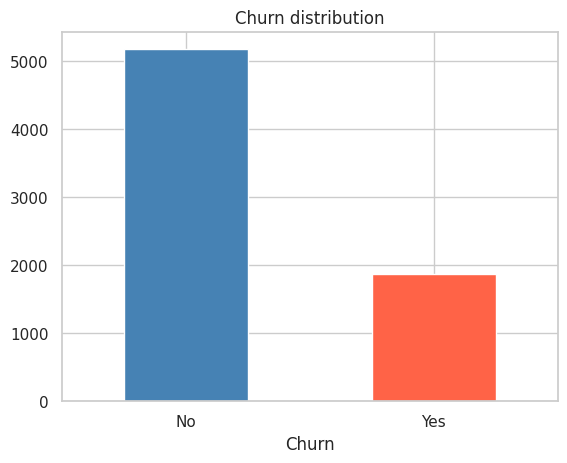

In [3]:
df["TotalCharges"] = pd.to_numeric(df["TotalCharges"], errors="coerce").fillna(0)
print(df["Churn"].value_counts())
print(df["Churn"].value_counts(normalize=True).round(3))

df["Churn"].value_counts().plot(kind="bar", color=["steelblue", "tomato"])
plt.title("Churn distribution")
plt.xticks(rotation=0)
plt.show()


# Churn distribution

- **No (stayed):** 73.5% (5,174 customers)
- **Yes (churned):** 26.5% (1,869 customers)

**Analysis:** the target variable is imbalanced, with churners as the minority class (imbalance ratio about 2.8:1). The imbalance is moderate, but a model that always predicts "No" would reach 73.5% accuracy without detecting any churner. Accuracy is therefore not a reliable metric here.

**Consequences for modeling:**
- Use a **stratified** train/test split to keep the same proportions.
- Handle the imbalance with **class weights** or **SMOTE**.
- Evaluate with **recall, F1-score and ROC-AUC** instead of accuracy.

Contract
Month-to-month    42.7
One year          11.3
Two year           2.8
Name: Churn, dtype: float64


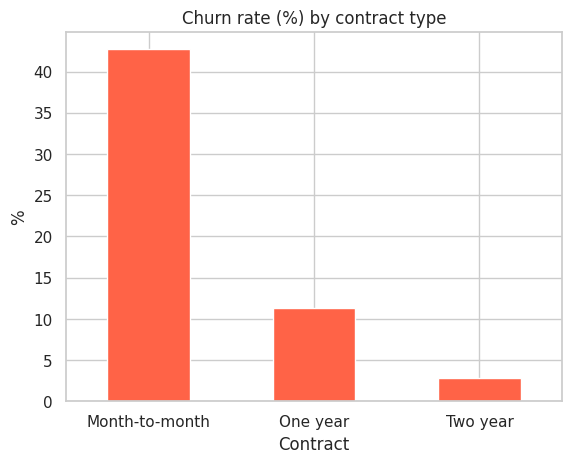

In [4]:
rate = df.groupby("Contract")["Churn"].apply(lambda s: (s == "Yes").mean() * 100)
print(rate.round(1))

rate.plot(kind="bar", color="tomato")
plt.title("Churn rate (%) by contract type")
plt.ylabel("%")
plt.xticks(rotation=0)
plt.show()

# Churn by contract type

| Contract | Churn rate |
|---|---|
| Month-to-month | 42.7% |
| One year | 11.3% |
| Two year | 2.8% |

**Analysis:** contract type is strongly associated with churn. Month-to-month customers churn about 15 times more than two-year customers. Since these customers have no commitment, they can leave at any time without cost.

**Business recommendation:** encourage migration to longer contracts through discounts or loyalty offers, and focus retention campaigns on month-to-month customers.

**Note:** this shows an association, not proof of causation. Customers who choose long contracts may already be more loyal.

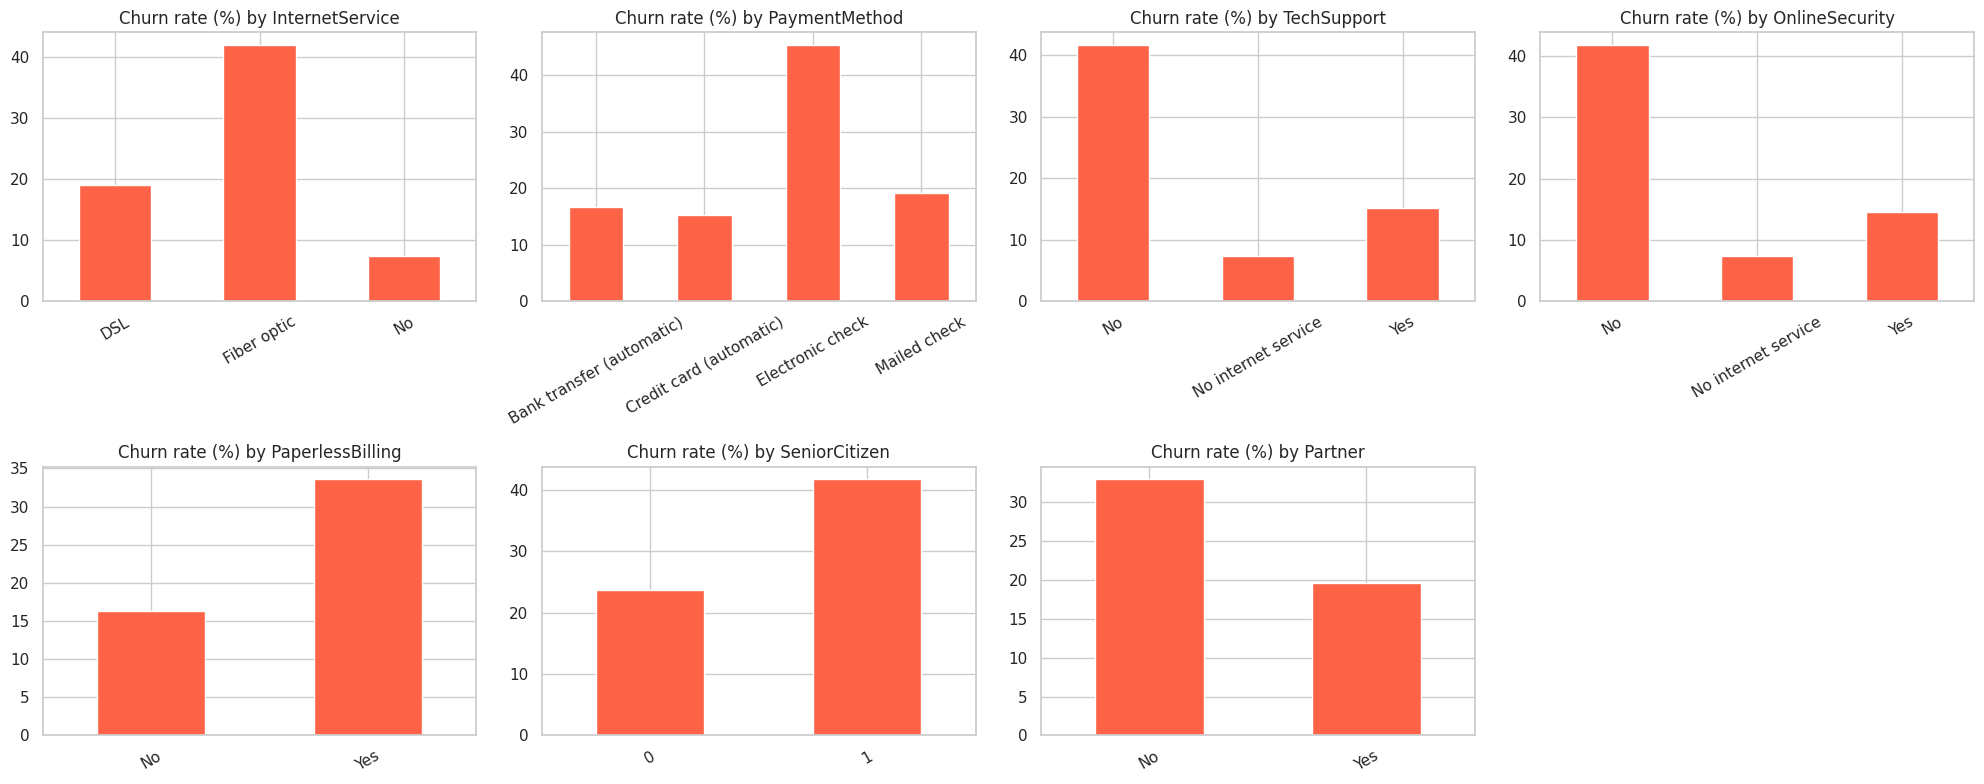

In [5]:
cat_cols = ["InternetService", "PaymentMethod", "TechSupport",
            "OnlineSecurity", "PaperlessBilling", "SeniorCitizen", "Partner"]

fig, axes = plt.subplots(2, 4, figsize=(20, 8))
for ax, col in zip(axes.flat, cat_cols):
    r = df.groupby(col)["Churn"].apply(lambda s: (s == "Yes").mean() * 100)
    r.plot(kind="bar", ax=ax, color="tomato")
    ax.set_title(f"Churn rate (%) by {col}")
    ax.set_xlabel("")
    ax.tick_params(axis="x", rotation=30)
axes.flat[-1].axis("off")
plt.tight_layout()
plt.show()

# Churn by customer and service characteristics

| Variable | Highest-churn group | Churn rate | Lowest-churn group | Churn rate |
|---|---|---|---|---|
| Internet service | Fiber optic | ~42% | No internet | ~7% |
| Payment method | Electronic check | ~45% | Credit card (automatic) | ~15% |
| Tech support | No | ~41% | Yes | ~15% |
| Online security | No | ~42% | Yes | ~15% |
| Paperless billing | Yes | ~34% | No | ~16% |
| Senior citizen | Yes | ~42% | No | ~24% |
| Partner | No | ~33% | Yes | ~20% |

**Analysis:**
- Fiber optic customers churn about twice as much as DSL customers, which may point to price or service quality issues.
- Customers who pay by electronic check churn about 3 times more than customers on automatic payment, a possible sign of lower engagement.
- Customers without tech support or online security churn nearly 3 times more than customers who have them.
- Seniors and customers living alone (no partner) churn more.

**Business recommendations:**
- Investigate fiber pricing and reliability.
- Encourage automatic payment with a small incentive.
- Offer free trials of tech support and online security.
- Design

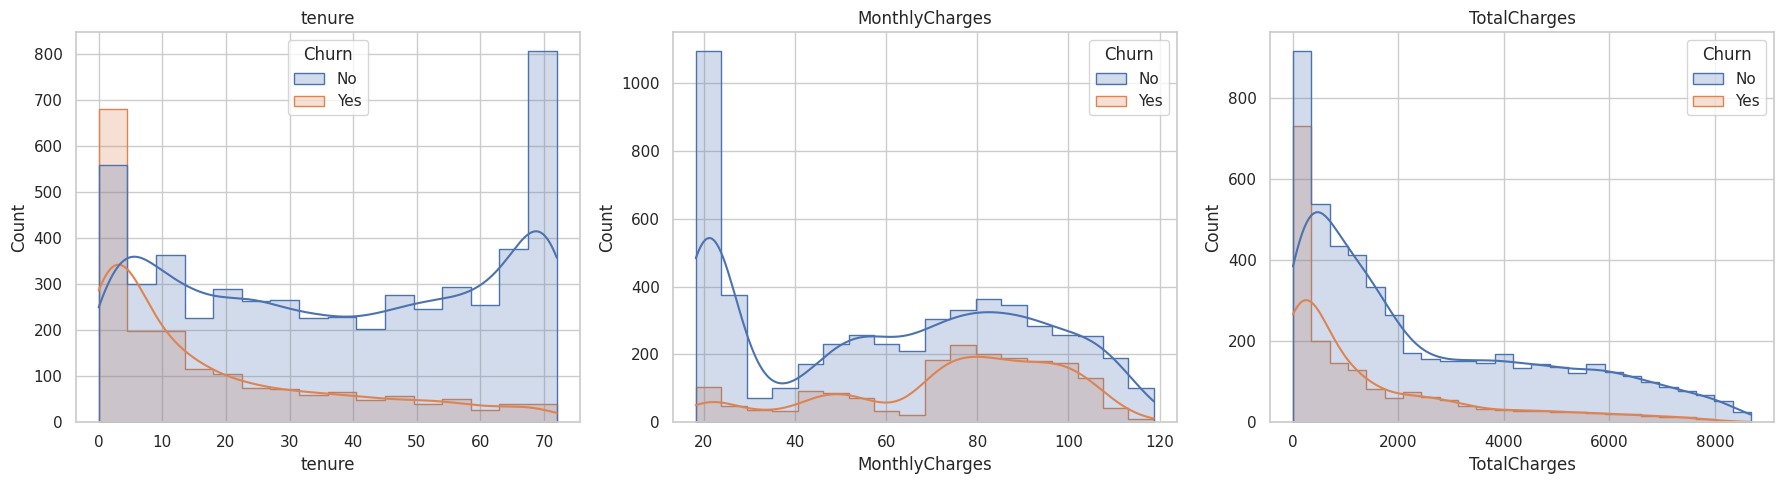

In [6]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
for ax, col in zip(axes, ["tenure", "MonthlyCharges", "TotalCharges"]):
    sns.histplot(data=df, x=col, hue="Churn", kde=True, ax=ax, element="step")
    ax.set_title(col)
plt.tight_layout()
plt.show()

# Churn and numeric variables

- **Tenure:** churn is highest in the first months. In the first bin (about 0 to 6 months), churners outnumber customers who stay. After that, churn falls steadily, and customers with a tenure around 70 months almost never leave.
- **Monthly charges:** customers with low bills (around 20) rarely churn, while churners are concentrated in the 70 to 105 range, where bills are higher.
- **Total charges:** most churners have low total charges, which reflects their short tenure rather than a separate effect.

**Business recommendations:**
- Set up onboarding and follow-up actions during the first 6 months.
- Review pricing and offers for customers paying 70 or more per month, especially fiber optic users.

**Caution:** TotalCharges is roughly tenure x MonthlyCharges, so the two variables are highly correlated and carry overlapping information. These are associations, not proof of causation.

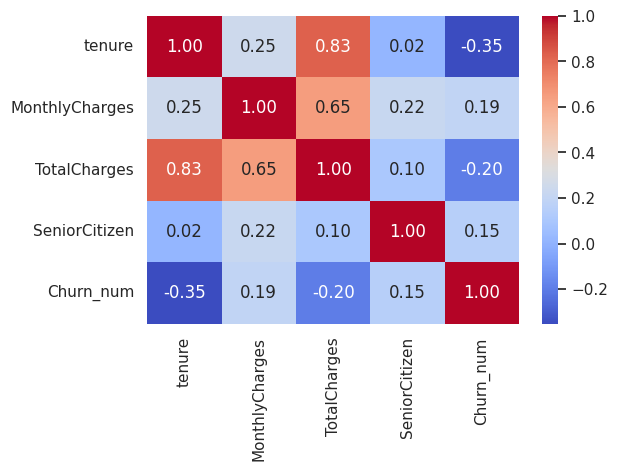

In [7]:
df_corr = df.copy()
df_corr["Churn_num"] = (df_corr["Churn"] == "Yes").astype(int)
corr = df_corr[["tenure", "MonthlyCharges", "TotalCharges", "SeniorCitizen", "Churn_num"]].corr()

plt.figure(figsize=(6, 4))
sns.heatmap(corr, annot=True, cmap="coolwarm", fmt=".2f")
plt.show()

# Correlation analysis

| Variable | Correlation with churn |
|---|---|
| tenure | -0.35 |
| TotalCharges | -0.20 |
| MonthlyCharges | +0.19 |
| SeniorCitizen | +0.15 |

**Analysis:**
- Tenure has the strongest (negative) correlation with churn: the longer a customer stays, the less likely they are to leave.
- MonthlyCharges and SeniorCitizen have weak positive correlations with churn.
- TotalCharges is strongly correlated with tenure (0.83) and MonthlyCharges (0.65), so it mostly duplicates their information.

**Consequences for modeling:**
- No single numeric variable explains churn on its own, so a multivariate model is needed.
- Multicollinearity is a risk for Logistic Regression. Consider scaling, regularization, or dropping TotalCharges.
- Categorical variables (Contract, InternetService, PaymentMethod) must be included, since correlation does not capture them.